<table>
    <tr>
    <th>
        <table>
            <tr>                                                                                   
                 <th  style="font-size:150%;ftext-align:left;background-color:#053061;color:white;">Valeur</th>
                 <th  style="font-size:150%;text-align:left;background-color:#053061;color:white;">Nom classe</th>
             </tr>
            <tr>
                <th  style="font-size:150%;text-align:left">0</th>
                <th  style="font-size:150%;text-align:left">basophil</th>
            </tr>
            <tr>
                <th  style="font-size:150%;text-align:left">1</th>
                <th  style="font-size:150%;text-align:left;">eosinophil</th>
            </tr>
            <tr>
                <th  style="font-size:150%;text-align:left">2</th>
                <th  style="font-size:150%;text-align:left">erythroblast</th>
            </tr>
            <tr>
                <th  style="font-size:150%;text-align:left">3</th>
                <th  style="font-size:150%;text-align:left">immature</th>
            </tr>
            <tr>
                <th  style="font-size:150%;text-align:left">4</th>
                <th  style="font-size:150%;text-align:left;">lymphocyte</th>
            </tr>
            <tr>
                <th  style="font-size:150%;text-align:left">5</th>
                <th  style="font-size:150%;text-align:left;">monocyte</th>
            </tr>            
            <tr>
                <th  style="font-size:150%;text-align:left">6</th>
                <th  style="font-size:150%;text-align:left;">neutrophil</th>
            </tr>            
            <tr>
                <th  style="font-size:150%;text-align:left">7</th>
                <th  style="font-size:150%;text-align:left">platelet</th>
            </tr>            
        </table>
    </th>
    <th>     
        <div style='padding:15px;color:#030aa7;font-size:240%;text-align: center;font-style: italic;font-weight: bold;font-family: Georgia, serif'>BloodMNIST<br> Standardized Biomedical Images</div>        
        <img src="https://raw.githubusercontent.com/rbizoi/FHU_TARGET_ScientificDays_2025/refs/heads/main/images/bloodMNIST8.png" width="512">
    </th>
    </tr>
</table>   

<div style='padding:15px;color:#030aa7;font-size:100%;text-align: left;font-family: Georgia, serif'><a href="https://github.com/MedMNIST/MedMNIST/tree/main">Veuillez vous référer à la page Github officielle pour plus de détails.</a></div>

>> **site du projet** : https://medmnist.com/

>> **site de données** : https://zenodo.org/records/10519652


# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Initialisation du document</div></b>

In [1]:
#!pip install tensorflow keras

In [2]:
import os
# import json
# @param ["tensorflow", "jax", "torch"]
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ['KERAS_BACKEND'] = 'tensorflow'
os.environ['TF_XLA_FLAGS'] = '--tf_xla_enable_xla_devices'
os.environ['TF_CPP_MIN_LOG_LEVEL']='5'

import tensorflow as tf
import keras
tf.get_logger().setLevel('ERROR')

E0000 00:00:1757663378.649568   77947 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757663378.652613   77947 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1757663378.659707   77947 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1757663378.659714   77947 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1757663378.659715   77947 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1757663378.659716   77947 computation_placer.cc:177] computation placer already registered. Please check linka

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:100%; border-radius:10px 10px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Import libriries </div></b>

In [3]:
import numpy as np, pandas as pd, seaborn as sns, warnings, os, sys, time
from matplotlib import pyplot as plt

warnings.filterwarnings(action="ignore")

if int(str(sns.__version__).split('.')[1]) > 8 :
    plt.style.use('seaborn-v0_8-darkgrid')
else:
    plt.style.use('seaborn-darkgrid')

sns.set(font_scale=2)

print(f"""La version des librairies utilisées :

Tensorflow : {tf.__version__}\tCUDA {tf.test.is_built_with_cuda()}\tGPU {tf.test.is_built_with_gpu_support()}\tXLA {tf.test.is_built_with_xla()}
Keras      : {keras.version()}
Pandas     : {pd.__version__}
NumPy      : {np.__version__}""")

La version des librairies utilisées :

Tensorflow : 2.19.1	CUDA True	GPU True	XLA True
Keras      : 3.12.0
Pandas     : 2.3.2
NumPy      : 1.26.4


## <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Importer les fichiers nécessaires à l’exécution</div></b>

In [4]:
!pip install gitpython

In [5]:
import requests, os

# Dépôt et chemin
def chargementDonnees(user="rbizoi",
                      repo="FHU_TARGET_ScientificDays_2025",
                      repertoire="outils",   # sous-dossier à récupérer
                      branch = "main"):

    url = f"https://api.github.com/repos/{user}/{repo}/contents/{repertoire}?ref={branch}"
    r = requests.get(url)
    files = r.json()
    
    os.makedirs(repertoire, exist_ok=True)
    
    for file in files:
        if file["type"] == "file":
            download_url = file["download_url"]
            file_data = requests.get(download_url).content
            with open(os.path.join(repertoire, file["name"]), "wb") as f:
                f.write(file_data)
            # print(f"Téléchargé : {file['name']}")
    
    print(f"Le répertoire - {repertoire} { 'a bien' if os.path.exists(repertoire) & os.path.isdir(repertoire) else 'n’a pas'} été chargé  ")

chargementDonnees(user="rbizoi",
                      repo="FHU_TARGET_ScientificDays_2025",
                      repertoire="outils",   # sous-dossier à récupérer
                      branch = "main")

repertoire = 'donnees/BloodMNIST'
# repertoire = 'donnees/BloodMNIST224x224-4'
# repertoire = 'donnees/BloodMNIST224x224-8'
# repertoire = 'donnees/BloodMNIST36x36-4'
# repertoire = 'donnees/BloodMNIST36x36-8'
# repertoire = 'donnees/BloodObjectDetection'
# repertoire = 'donnees/BloodSegmented'

chargementDonnees( user="rbizoi",
                   repo="FHU_TARGET_ScientificDays_2025",
                   repertoire=repertoire,   # sous-dossier à récupérer
                   branch = "main")
chargementDonnees( user="rbizoi",
                   repo="FHU_TARGET_ScientificDays_2025",
                   repertoire=f'{repertoire}/apprentissage',   # sous-dossier à récupérer
                   branch = "main")
chargementDonnees( user="rbizoi",
                   repo="FHU_TARGET_ScientificDays_2025",
                   repertoire=f'{repertoire}/validation',   # sous-dossier à récupérer
                   branch = "main")

Le répertoire - outils a bien été chargé  
Le répertoire - donnees/BloodMNIST a bien été chargé  
Le répertoire - donnees/BloodMNIST/apprentissage a bien été chargé  
Le répertoire - donnees/BloodMNIST/validation a bien été chargé  


# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Outils du document</div></b>

In [6]:
sys.path.append(os.path.abspath('outils/'))

In [7]:
if 'configProjet' in sys.modules.keys():  del(sys.modules['configProjet'])
if 'configModele' in sys.modules.keys():  del(sys.modules['configModele'])

In [8]:
from configProjet import palette, initParametresProjet
from configProjet import afficheHistoriqueEntrainement, afficheProbabilites, afficheMatriceConfusion, afficheDataset, afficheDistributionsPipe

In [9]:
from configModele import modelDictionnaire, initParametresExecution, getPipelineDataset
from configModele import creationCompilationModele, creationRappelsExecution, entrainementModele
from configModele import sauvegarderModel, sauvegardeHistorique, executeApprentissageChoixClassifieurs
from configModele import modelPersonalise

I0000 00:00:1757663382.911311   77947 service.cc:152] XLA service 0x652b32f7ad60 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1757663382.911328   77947 service.cc:160]   StreamExecutor device (0): Host, Default Version
I0000 00:00:1757663383.017614   77947 service.cc:152] XLA service 0x652b32f1d7a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1757663383.017633   77947 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
I0000 00:00:1757663383.017634   77947 service.cc:160]   StreamExecutor device (1): NVIDIA GeForce RTX 3090, Compute Capability 8.6
I0000 00:00:1757663383.024437   77947 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22198 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:02:00.0, compute capability: 8.9
I0000 00:00:1757663383.024973   77947 gpu_device.cc:2019] C

# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Paramétrés de l’exécution et les flux de lecture des fichiers TFRecors</div></b>

In [10]:
image_size,batch_size,epochs,dictLabels,nombreClasses,pipelineApprentissage,pipelineValidation = \
       initParametresExecution(image_size=(28, 28, 3),
                            batch_size = 32,
                            epochs=128,
                            repertoire=repertoire,
                            cycle_length=None,
                            deterministic=None,
                            repetition=1,
                            bufferAleatoire=1024)

In [11]:
print(f"""
  repertoire    = {repertoire}
  image_size    = {image_size}
  batch_size    = {batch_size}
  epochs        = {epochs}
  nombreClasses = {nombreClasses}
  dictLabels    = {dictLabels}
       """)


  repertoire    = donnees/BloodMNIST
  image_size    = (28, 28, 3)
  batch_size    = 32
  epochs        = 128
  nombreClasses = 8
  dictLabels    = {0: 'basophil', 1: 'eosinophil', 2: 'erythroblast', 3: 'immature', 4: 'lymphocyte', 5: 'monocyte', 6: 'neutrophil', 7: 'platelet'}
       


# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Affichage données</div></b>

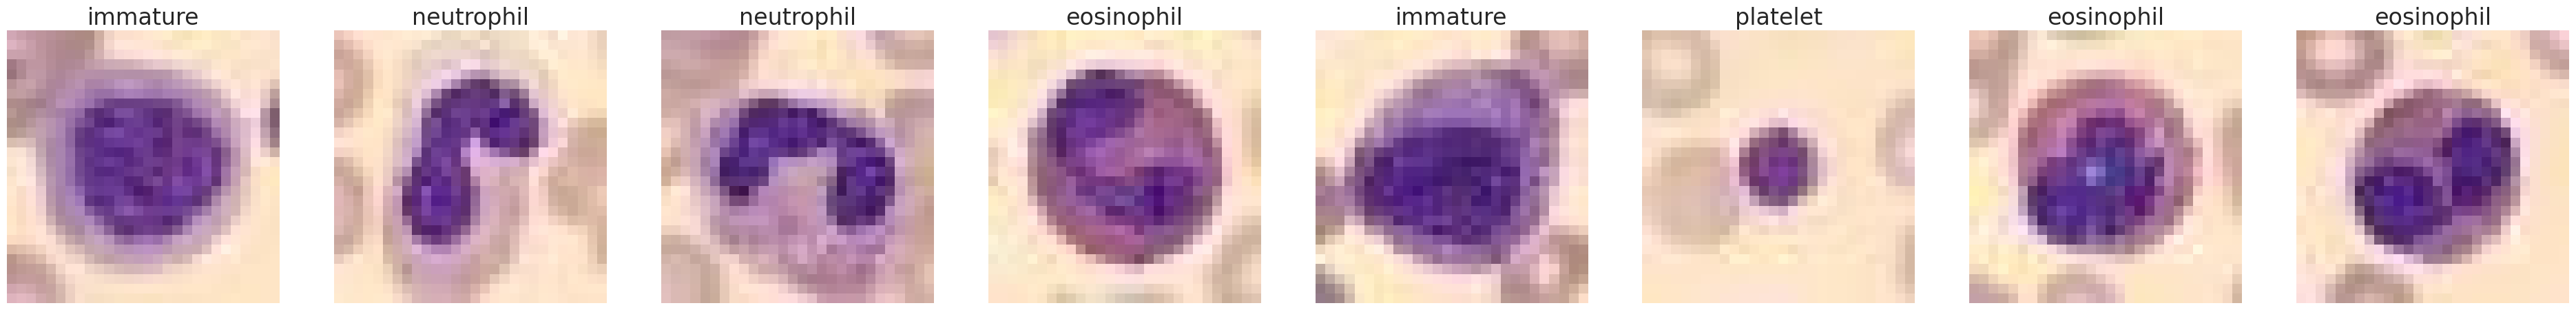

In [12]:
images, labels = next(iter(pipelineApprentissage))
nombresImages = 8
afficheDataset(images, labels,nombresImages,6*nombresImages,dictLabels,cmap=None)

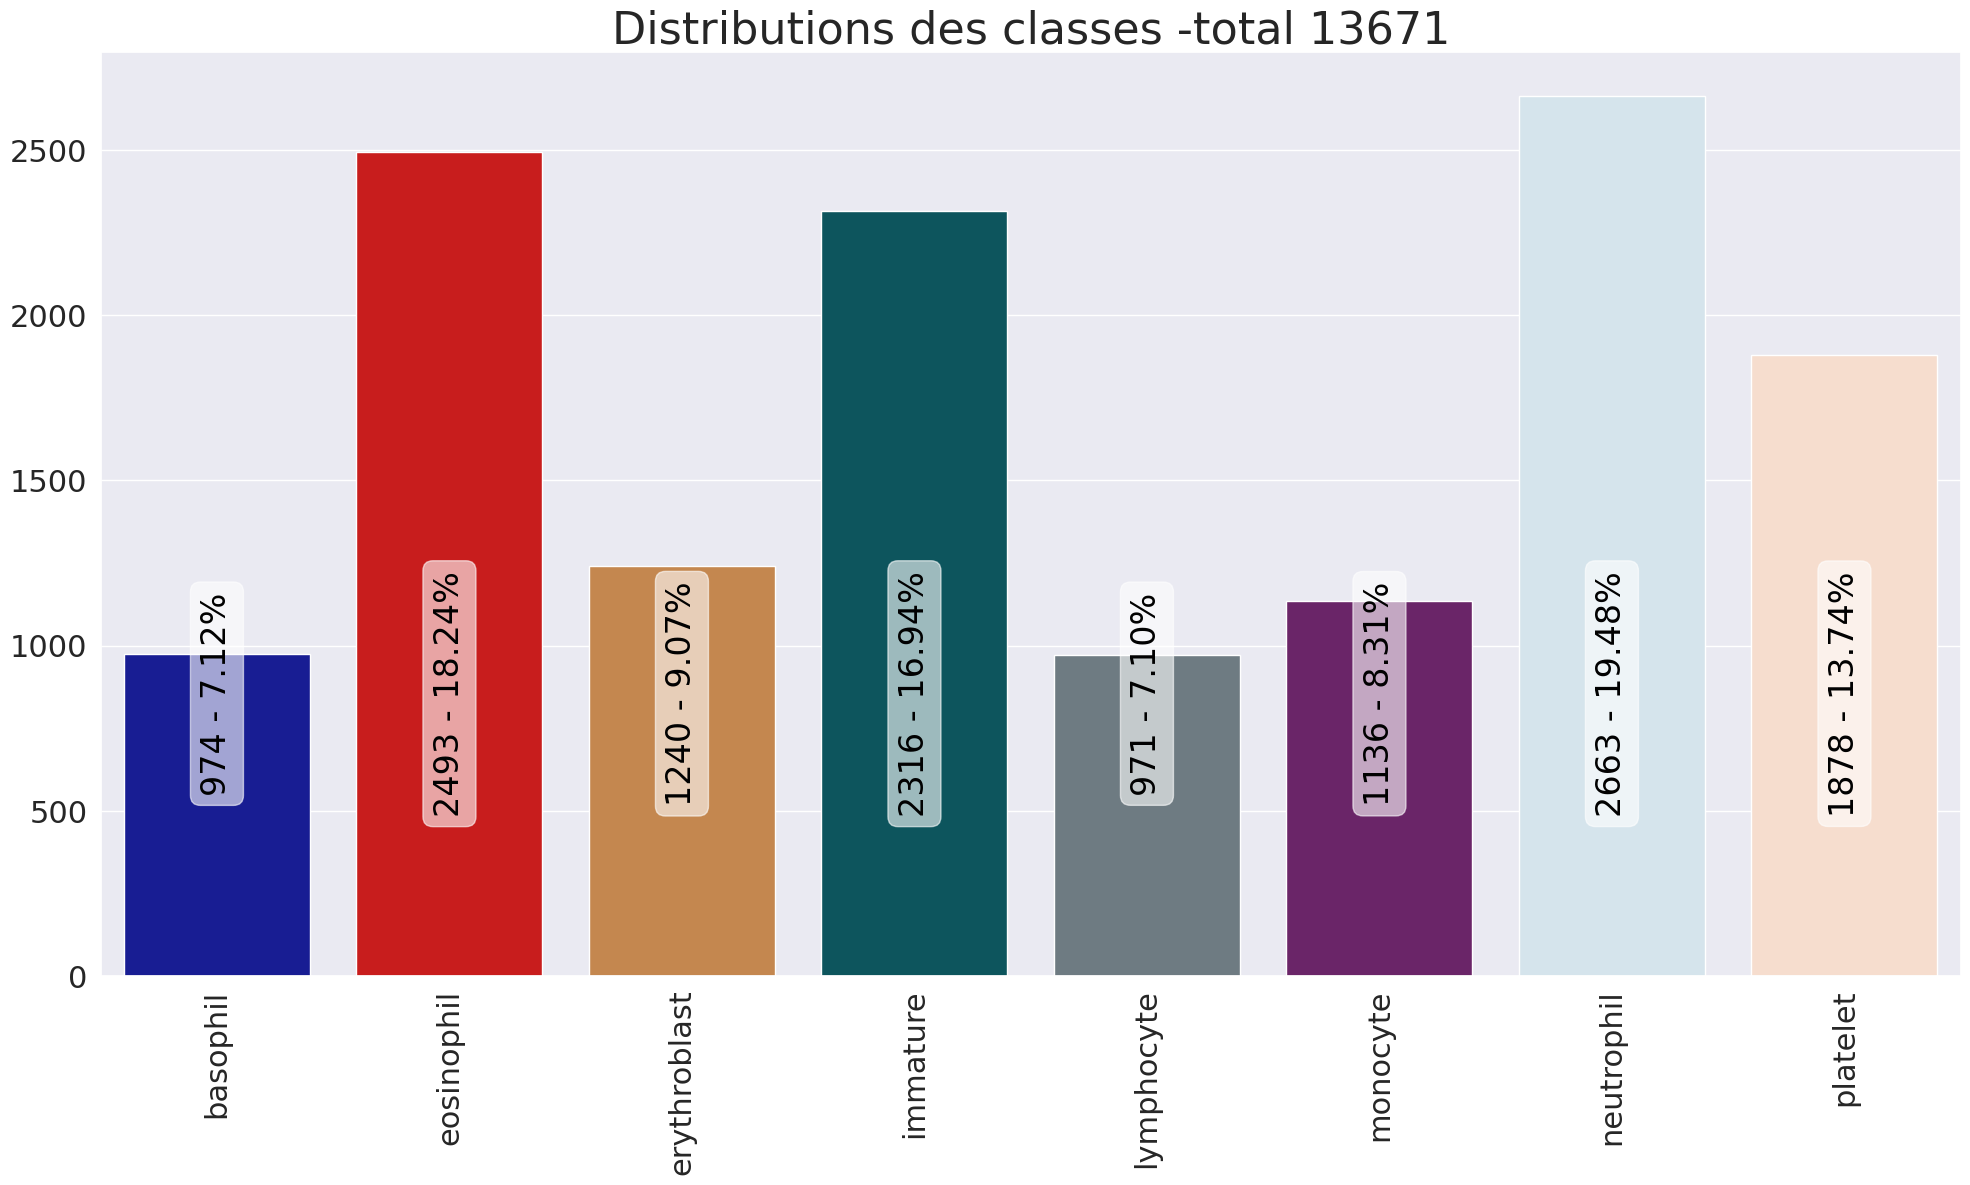

In [13]:
afficheDistributionsPipe(pipelineApprentissage, dictLabels, palette, repertoireEnregistrement=None)

# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Choix du modèle</div></b>

In [14]:
nomModel = 'CNN-PersonaliseMNIST'

In [15]:
repertoireEnregistrement,repertoireSauvegardes,repertoireModelCKP,repertoireModelSauvegarde,repertoireModelLogs = \
            initParametresProjet(nomProjet=f"0.1-bloodMNIST-{nomModel}-bs{batch_size:02d}-epochs{epochs:03d}",repertoireProjet='ResultatsExecutions')

# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Création et compilation d'un modèle</div></b>

## <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Conception du modèle</div></b>

In [16]:
def modelCNNSimple(image_size,
                   num_classes,
                   activation,
                   nb_filtres):

    preprocessData = tf.keras.Sequential([
            keras.layers.Rescaling(1.0 / 255),
        ])

    inputs = keras.Input(shape=image_size)

    # Entry block
    x = keras.layers.Conv2D(nb_filtres, kernel_size=(3,3), strides=(1,1), padding="same",kernel_initializer='glorot_normal')(inputs)
    x = keras.layers.BatchNormalization(scale=False)(x)
    x = keras.layers.Activation(activation)(x)

    x = keras.layers.Conv2D(nb_filtres, kernel_size=(1,1), strides=(1,1), padding="same",kernel_initializer='glorot_normal')(x)
    x = keras.layers.BatchNormalization(scale=False)(x)
    x = keras.layers.Activation(activation)(x)

    x = keras.layers.Conv2D(nb_filtres, kernel_size=(3,3), strides=(2,2), padding="same",kernel_initializer='glorot_normal')(x)
    x = keras.layers.BatchNormalization(scale=False)(x)
    x = keras.layers.Activation(activation)(x)

    x = keras.layers.Conv2D(nb_filtres//2, kernel_size=(1,1), strides=(1,1), padding="same",kernel_initializer='glorot_normal')(x)
    x = keras.layers.BatchNormalization(scale=False)(x)
    x = keras.layers.Activation(activation)(x)

    x = keras.layers.Conv2D(nb_filtres//2, kernel_size=(3,3), strides=(1,1), padding="same",kernel_initializer='glorot_normal')(x)
    x = keras.layers.BatchNormalization(scale=False)(x)
    x = keras.layers.Activation(activation)(x)

    x = keras.layers.Conv2D(nb_filtres//2, kernel_size=(3,3), strides=(2,2), padding="same",kernel_initializer='glorot_normal')(x)
    x = keras.layers.BatchNormalization(scale=False)(x)
    x = keras.layers.Activation(activation)(x)

    x = keras.layers.GlobalAveragePooling2D()(x)

    x = keras.layers.Dropout(0.5)(x)
    outputs = keras.layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs, name='ModelPersonaliseMNIST')

In [17]:
model = modelCNNSimple(image_size=image_size,
                       num_classes=nombreClasses,
                       activation=keras.ops.gelu,
                       nb_filtres = 32)

In [18]:
model.compile(
        optimizer=keras.optimizers.AdamW(1e-03),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy')],
    )

In [19]:
model.summary()

Model: "ModelPersonaliseMNIST"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 32)     │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 16)     │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 16)     │            48 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 16)     │            48 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 7, 7, 16)       │            48 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 16)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 16,936 (66.16 KB)

 Trainable params: 16,648 (65.03 KB)

 Non-trainable params: 288 (1.12 KB)

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:100%; border-radius:10px 10px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Rappels d’exécution (callbacks)</div></b>

In [20]:
def evolutionTauxApprentissage(epoch,
                               initial_lrate=1e-04,
                               max_lrate=1e-04,
                               min_lrate=1e-05,
                               epochs_runup_lrate=0,
                               epochs_sustain_lrate=0,
                               drop_lrate=0.98):
    # epochs_drop = epochs * 0.1
    if epoch < epochs_runup_lrate:
        lrate = (max_lrate - initial_lrate) / epochs_runup_lrate * epoch + initial_lrate
    elif epoch < epochs_runup_lrate + epochs_sustain_lrate:
        lrate = max_lrate
    else:
        lrate = (max_lrate - min_lrate) * drop_lrate**(epoch - epochs_runup_lrate - epochs_sustain_lrate) + min_lrate
    return lrate

filename = os.path.join(repertoireModelSauvegarde, 'modelVLoss.keras')
learningRate = keras.callbacks.LearningRateScheduler(evolutionTauxApprentissage)
checkpointLoss = keras.callbacks.ModelCheckpoint(filename,
                                                    monitor = 'val_loss',
                                                    verbose = 1,
                                                    save_best_only = True,
                                                    mode = 'min')

backupAndRestore = keras.callbacks.BackupAndRestore(backup_dir=repertoireModelCKP)
tensorBoard = keras.callbacks.TensorBoard(log_dir=repertoireModelLogs)

arretPrecoce = keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, verbose=1)

callbacks = [learningRate,checkpointLoss,backupAndRestore,tensorBoard,arretPrecoce]

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:100%; border-radius:10px 10px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Evolution du taux d'apprentissage</div></b>

L'évolution du taux d'apprentissage : du 0.0001 à 1.69e-05


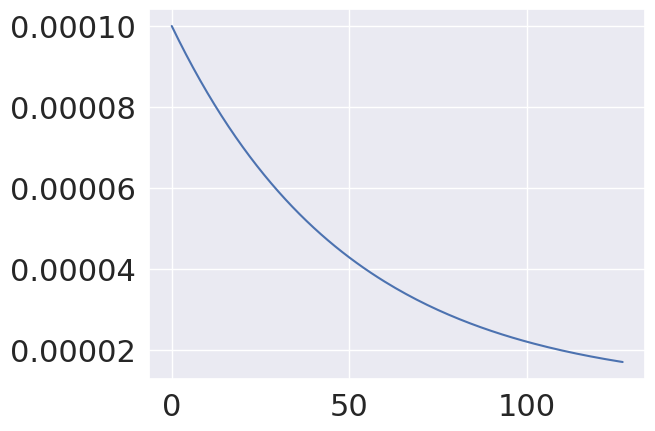

In [21]:
rng = [i for i in range(epochs)]
y = [evolutionTauxApprentissage(x) for x in rng]
plt.plot(rng, y)

print(f"L'évolution du taux d'apprentissage : du {y[0]:.3g} à {min(y):.3g}")

# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Entrainement du modèle</div></b>


In [22]:
historiqueApprentissage, model = entrainementModele( model,
                                                     pipelineApprentissage,
                                                     pipelineValidation,
                                                     epochs,
                                                     batch_size,
                                                     callbacks,
                                                     2, #verbose=2,
                                                     repertoireModelSauvegarde)

Epoch 1/128


I0000 00:00:1757659746.855881   38906 cuda_dnn.cc:529] Loaded cuDNN version 91300
I0000 00:00:1757659748.666462   38906 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.



Epoch 1: val_loss improved from None to 1.64041, saving model to ResultatsExecutions/0.1-bloodMNIST-CNN-PersonaliseMNIST-bs32-epochs128/model.sauvegardes/sauvegarde/modelVLoss.keras
428/428 - 6s - 15ms/step - accuracy: 0.3218 - loss: 1.8624 - val_accuracy: 0.5095 - val_loss: 1.6404 - learning_rate: 1.0000e-04
Epoch 2/128

Epoch 2: val_loss improved from 1.64041 to 1.24765, saving model to ResultatsExecutions/0.1-bloodMNIST-CNN-PersonaliseMNIST-bs32-epochs128/model.sauvegardes/sauvegarde/modelVLoss.keras
428/428 - 1s - 3ms/step - accuracy: 0.5731 - loss: 1.4724 - val_accuracy: 0.6656 - val_loss: 1.2477 - learning_rate: 9.8200e-05
Epoch 3/128

Epoch 3: val_loss improved from 1.24765 to 1.04596, saving model to ResultatsExecutions/0.1-bloodMNIST-CNN-PersonaliseMNIST-bs32-epochs128/model.sauvegardes/sauvegarde/modelVLoss.keras
428/428 - 1s - 2ms/step - accuracy: 0.6387 - loss: 1.2661 - val_accuracy: 0.7615 - val_loss: 1.0460 - learning_rate: 9.6436e-05
Epoch 4/128

Epoch 4: val_loss impro

# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Affichage historique de l'apprentissage </div></b>

In [23]:
historique = sauvegardeHistorique(historiqueApprentissage,
                                  repertoireSauvegardes,
                                  nomSauvegarde=f'historique-{nomModel}-bs{batch_size:02d}-epochs{epochs:03d}')

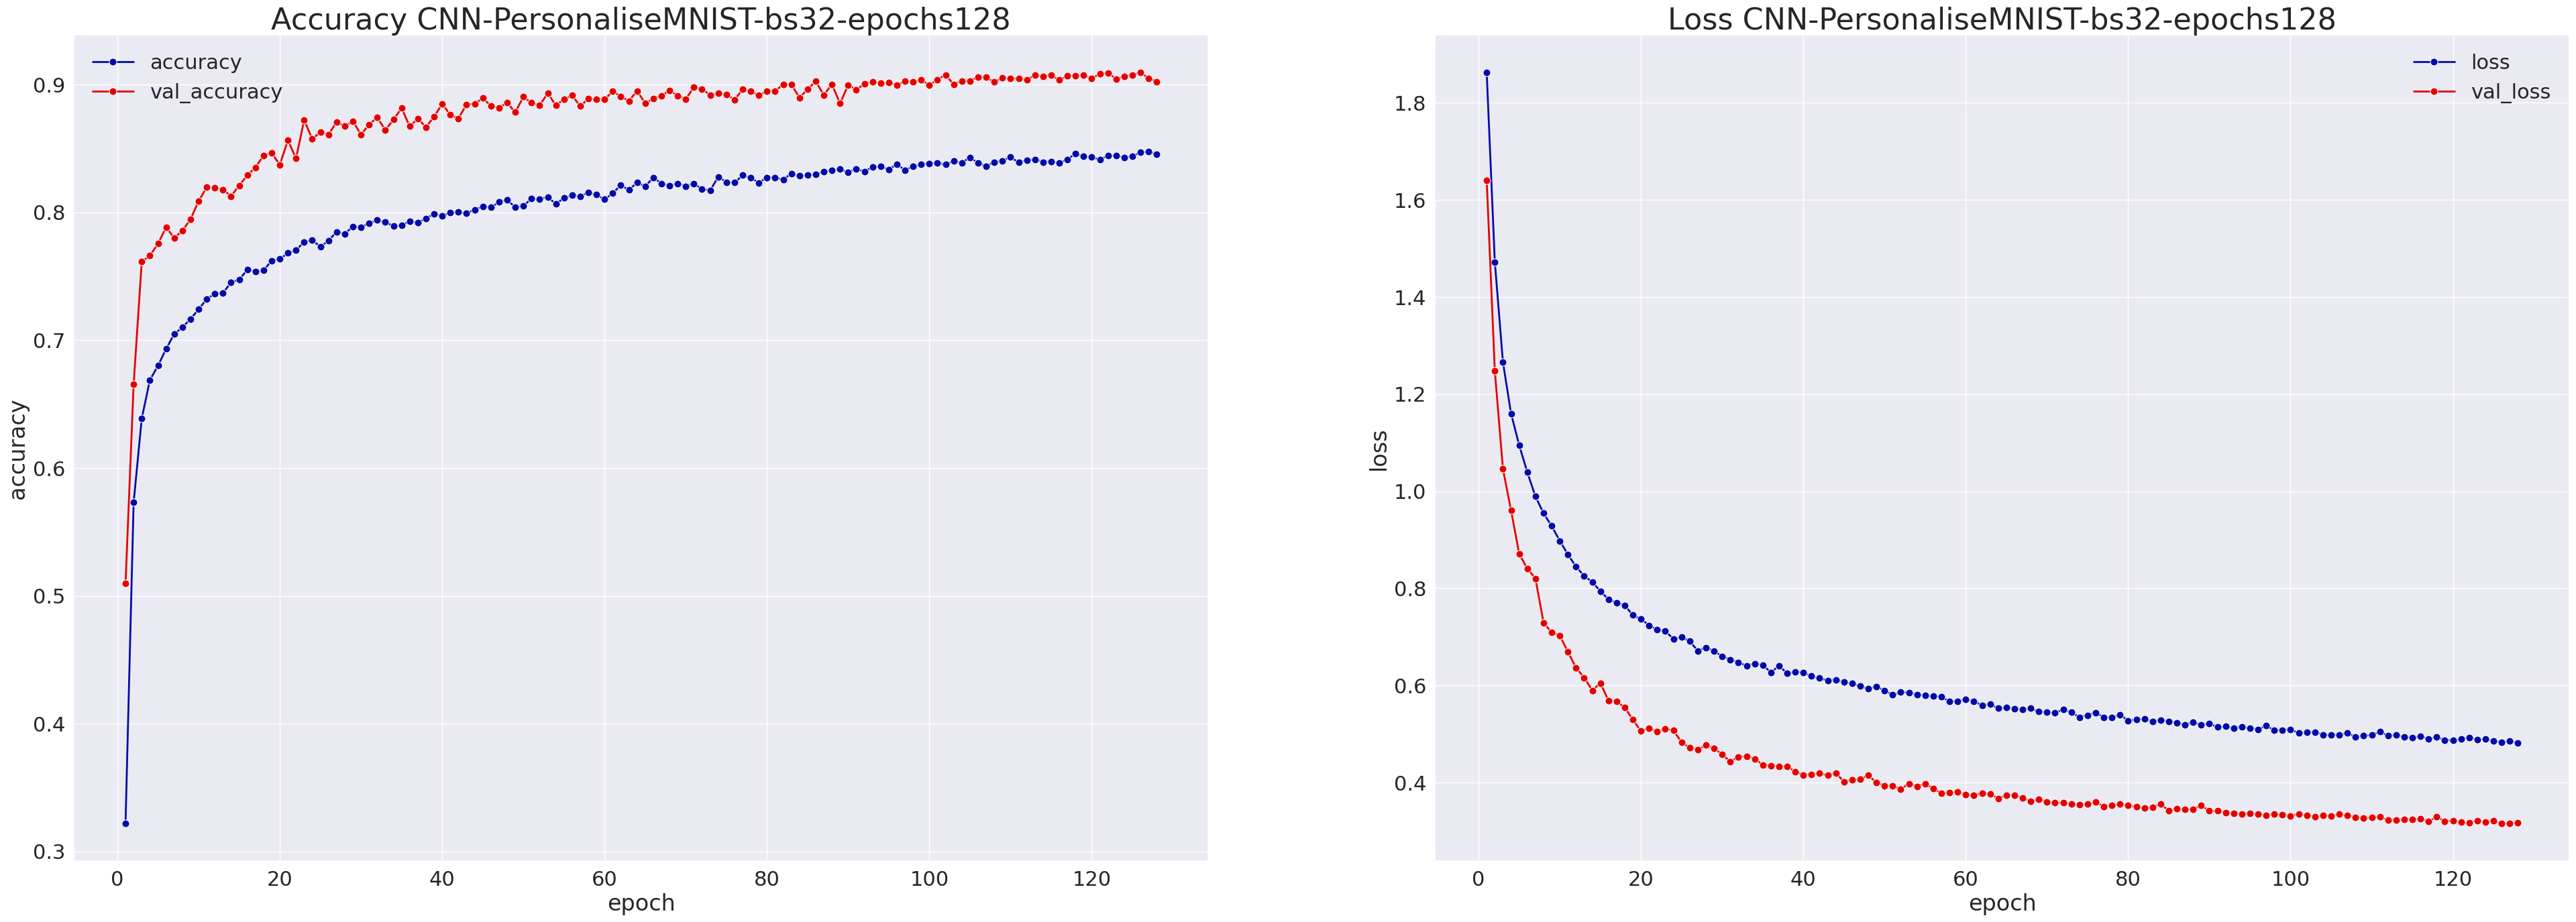

In [24]:
afficheHistoriqueEntrainement(historique, palette, f'{nomModel}-bs{batch_size:02d}-epochs{epochs:03d}', repertoireEnregistrement)

# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Sauvegarde du modèle </div></b>

In [25]:
model.save(os.path.join(repertoireModelSauvegarde,f'{nomModel}-bs{batch_size:02d}-epochs{epochs:03d}.keras'))

# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Inférence</div></b>

In [26]:
for i, (img,lab) in enumerate(pipelineValidation):
    images, labels = img if i==0 else tf.concat([images,img], 0), lab if i==0 else tf.concat([labels,lab], 0)

In [27]:
probabilities = model.predict(images, verbose=0)
predictions = np.argmax(probabilities, axis=-1)

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:100%; border-radius:10px 10px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Probabilités pour les 8 premiers prédictions </div></b>

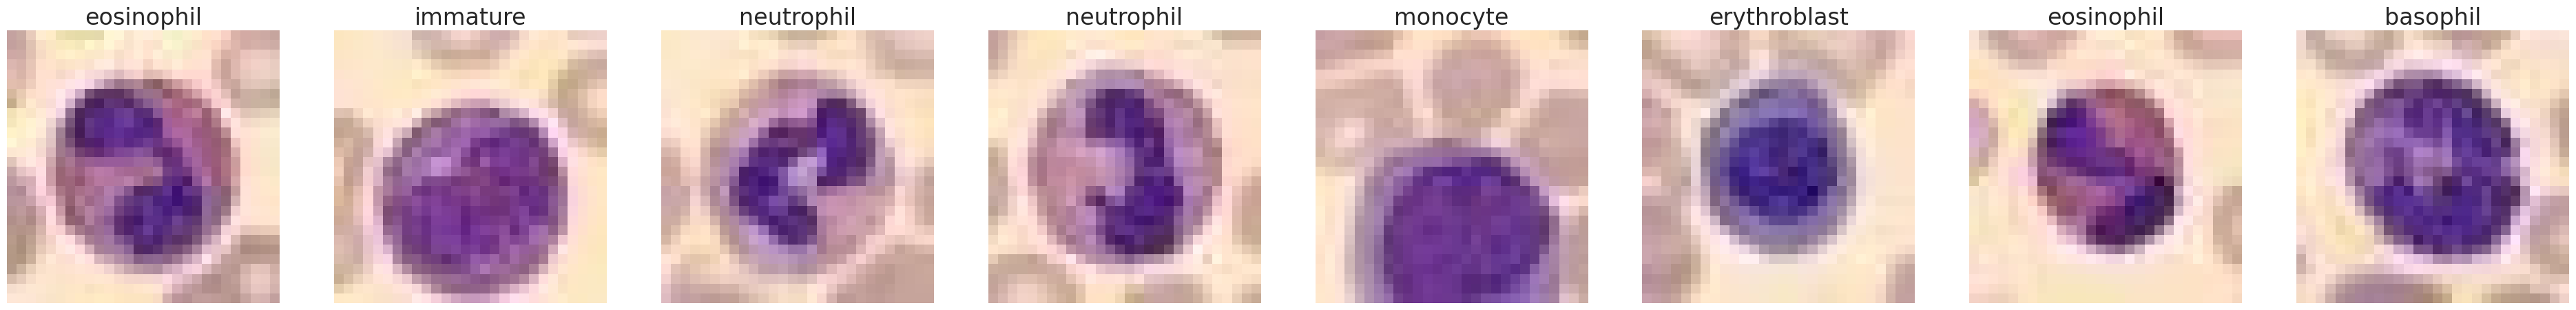

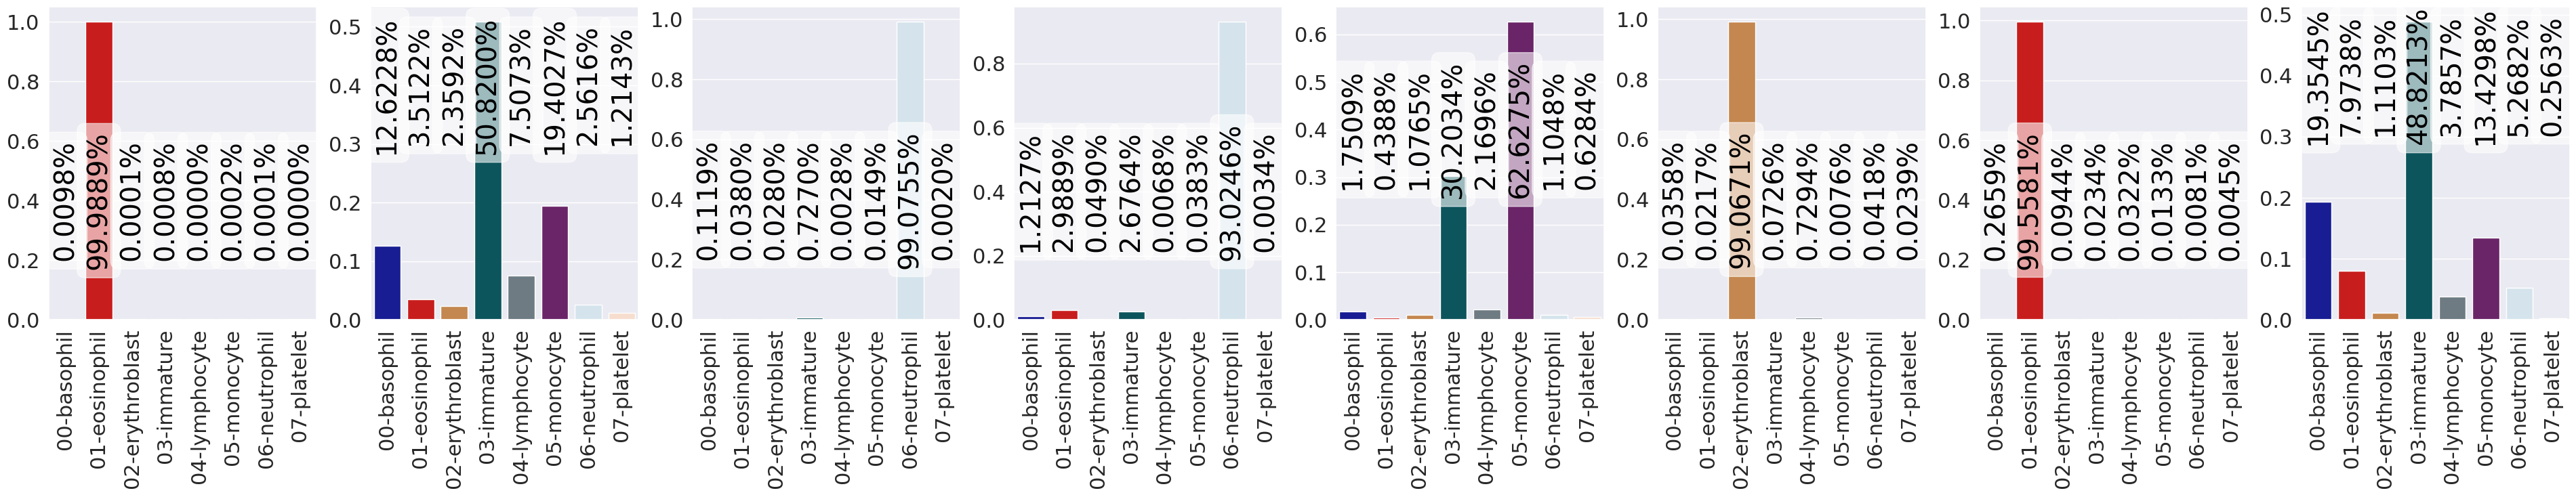

In [28]:
nombresImages = 8
afficheDataset(images, labels,nombresImages,6*nombresImages,dictLabels,cmap=None)
fig, ax = plt.subplots(nrows=1, ncols=nombresImages,figsize=(6*nombresImages,6));
for i in range(nombresImages):
    afficheProbabilites(probabilities,ind=i,ax=ax[i], dictLabels=dictLabels)

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:100%; border-radius:10px 10px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Matrice de Confusion </div></b>

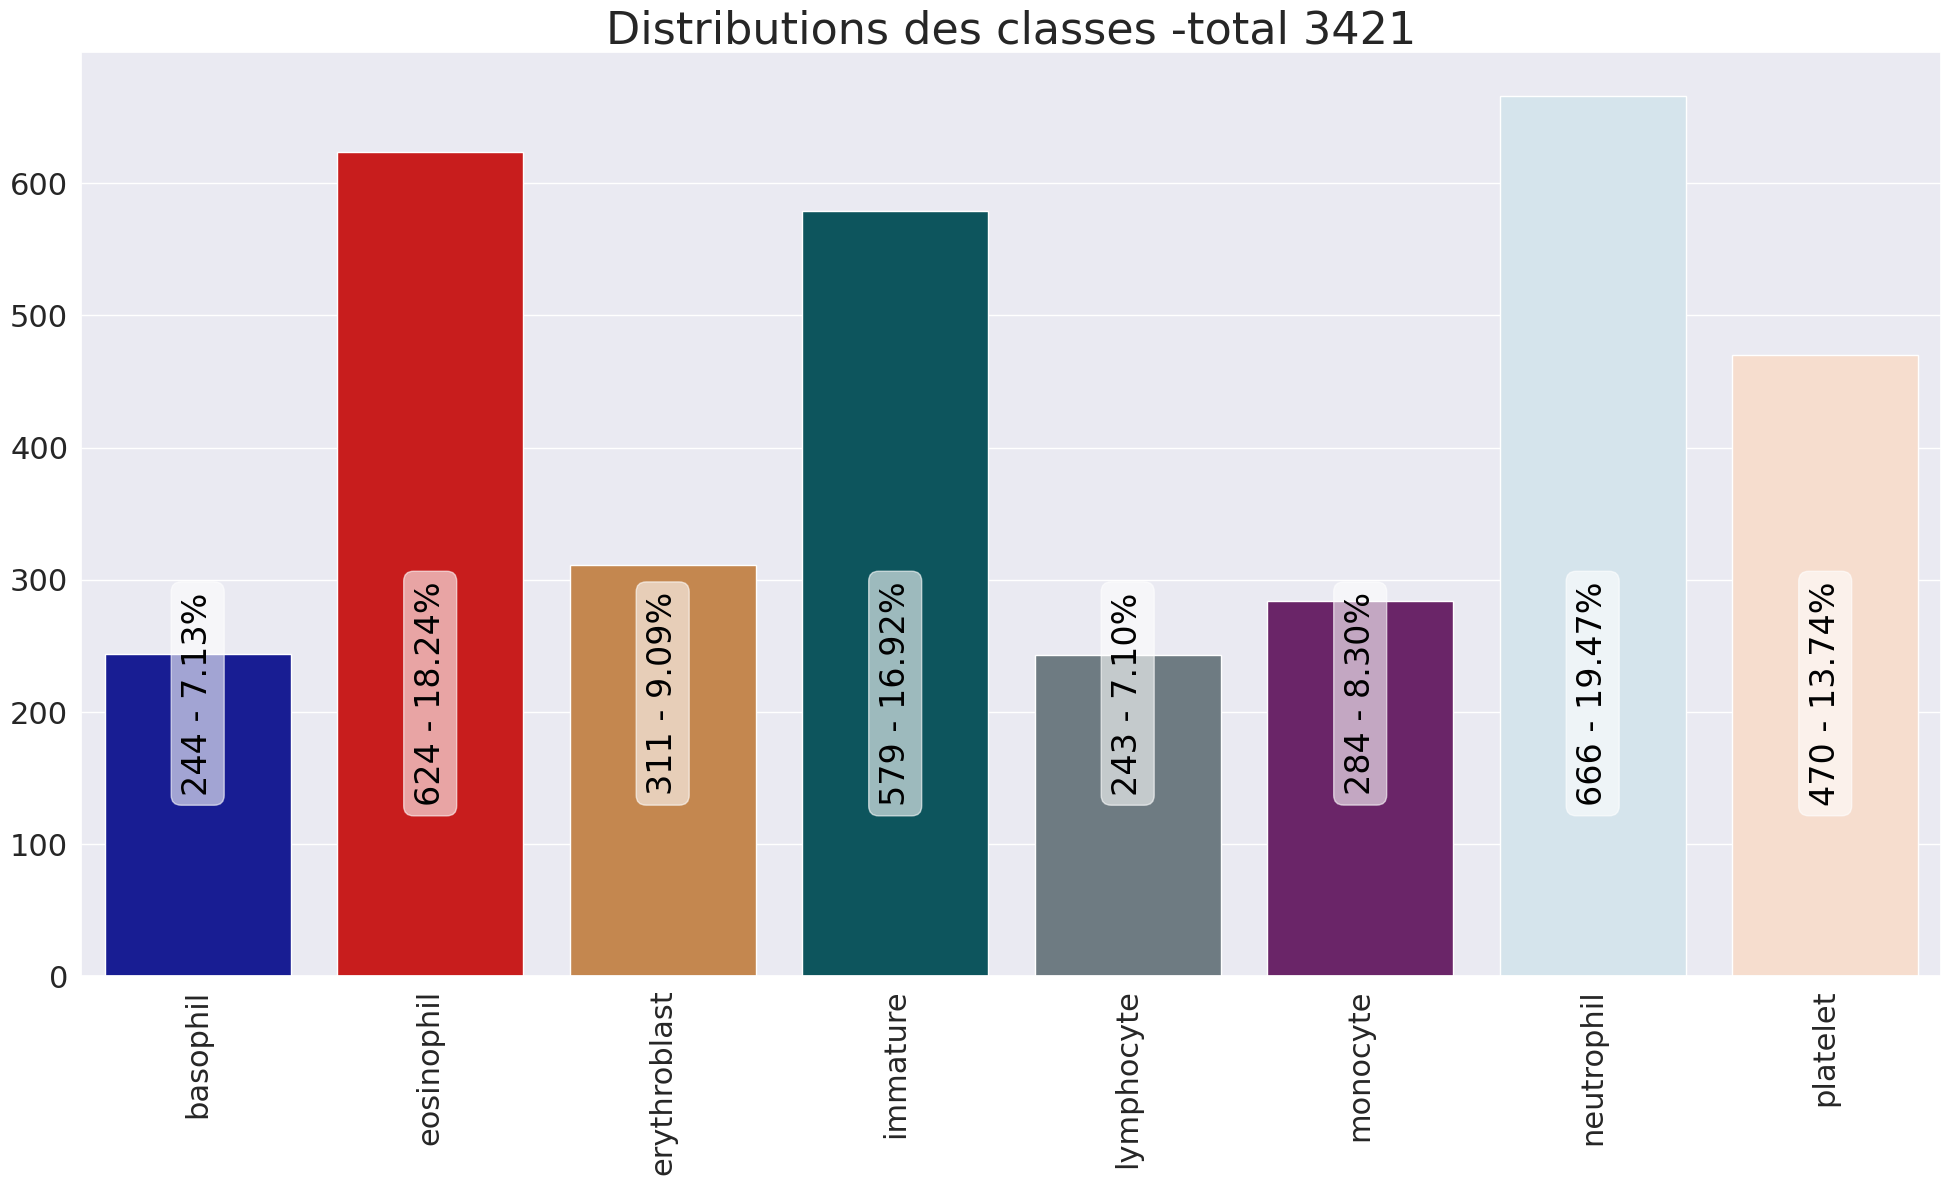

In [29]:
afficheDistributionsPipe(pipelineValidation, dictLabels, palette, repertoireEnregistrement=None)

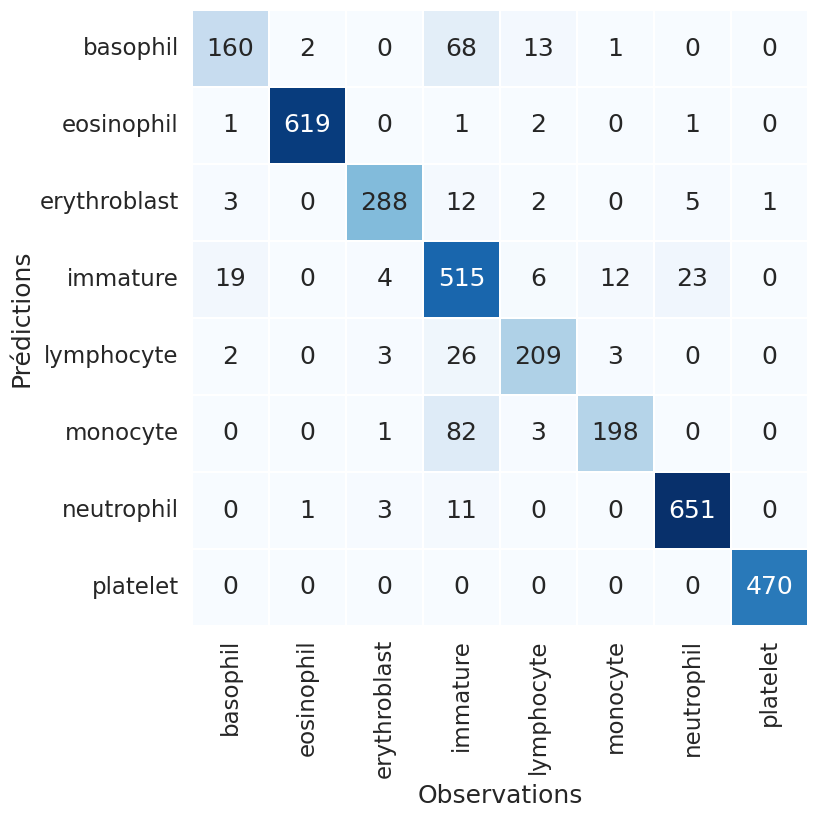

In [30]:
afficheMatriceConfusion(observations=labels,predictions=predictions,dictLabels=dictLabels, repertoireEnregistrement=repertoireEnregistrement,
                        nom_essai = f'{nomModel}-bs{batch_size:02d}-epochs{epochs:03d}')

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:100%; border-radius:10px 10px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Résultats de l’apprentissage</div></b>

107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 594us/step
Area under the ROC curve : 0.9905	--	Exécution  :2.77s


,Classe,aucROC,avgPrecRec,f1,f2,f05,accuracy,precision,sensibilite,vrais_positifs,vrais_negatifs,faux_positifs,faux_negatifs,total_positifs,essai
0,global,0.990519,0.969172,0.908680,0.908035,0.912129,0.909091,0.916135,0.909091,3110,23636,311,311,3421,CNN-PersonaliseMNIST-bs32-epochs128
1,basophil,0.986139,0.890796,0.745921,0.689061,0.813008,0.968138,0.864865,0.655738,160,3152,25,84,244,CNN-PersonaliseMNIST-bs32-epochs128
2,eosinophil,0.999586,0.991088,0.993579,0.992623,0.994537,0.997662,0.995177,0.991987,619,2794,3,5,624,CNN-PersonaliseMNIST-bs32-epochs128
3,erythroblast,0.992553,0.974307,0.944262,0.933247,0.955541,0.990061,0.963211,0.926045,288,3099,11,23,311,CNN-PersonaliseMNIST-bs32-epochs128
4,immature,0.970654,0.871398,0.795981,0.849555,0.748764,0.922830,0.720280,0.889465,515,2642,200,64,579,CNN-PersonaliseMNIST-bs32-epochs128
5,lymphocyte,0.993383,0.939194,0.874477,0.865783,0.883347,0.982461,0.889362,0.860082,209,3152,26,34,243,CNN-PersonaliseMNIST-bs32-epochs128
6,monocyte,0.984535,0.894546,0.795181,0.733333,0.868421,0.970184,0.925234,0.697183,198,3121,16,86,284,CNN-PersonaliseMNIST-bs32-epochs128
7,neutrophil,0.997315,0.993795,0.967311,0.973385,0.961311,0.987138,0.957353,0.977477,651,2726,29,15,666,CNN-PersonaliseMNIST-bs32-epochs128
8,platelet,0.999987,0.999917,0.998937,0.999575,0.998301,0.999708,0.997877,1.000000,470,2950,1,0,470,CNN-PersonaliseMNIST-bs32-epochs128


<Figure size 1800x1800 with 0 Axes>

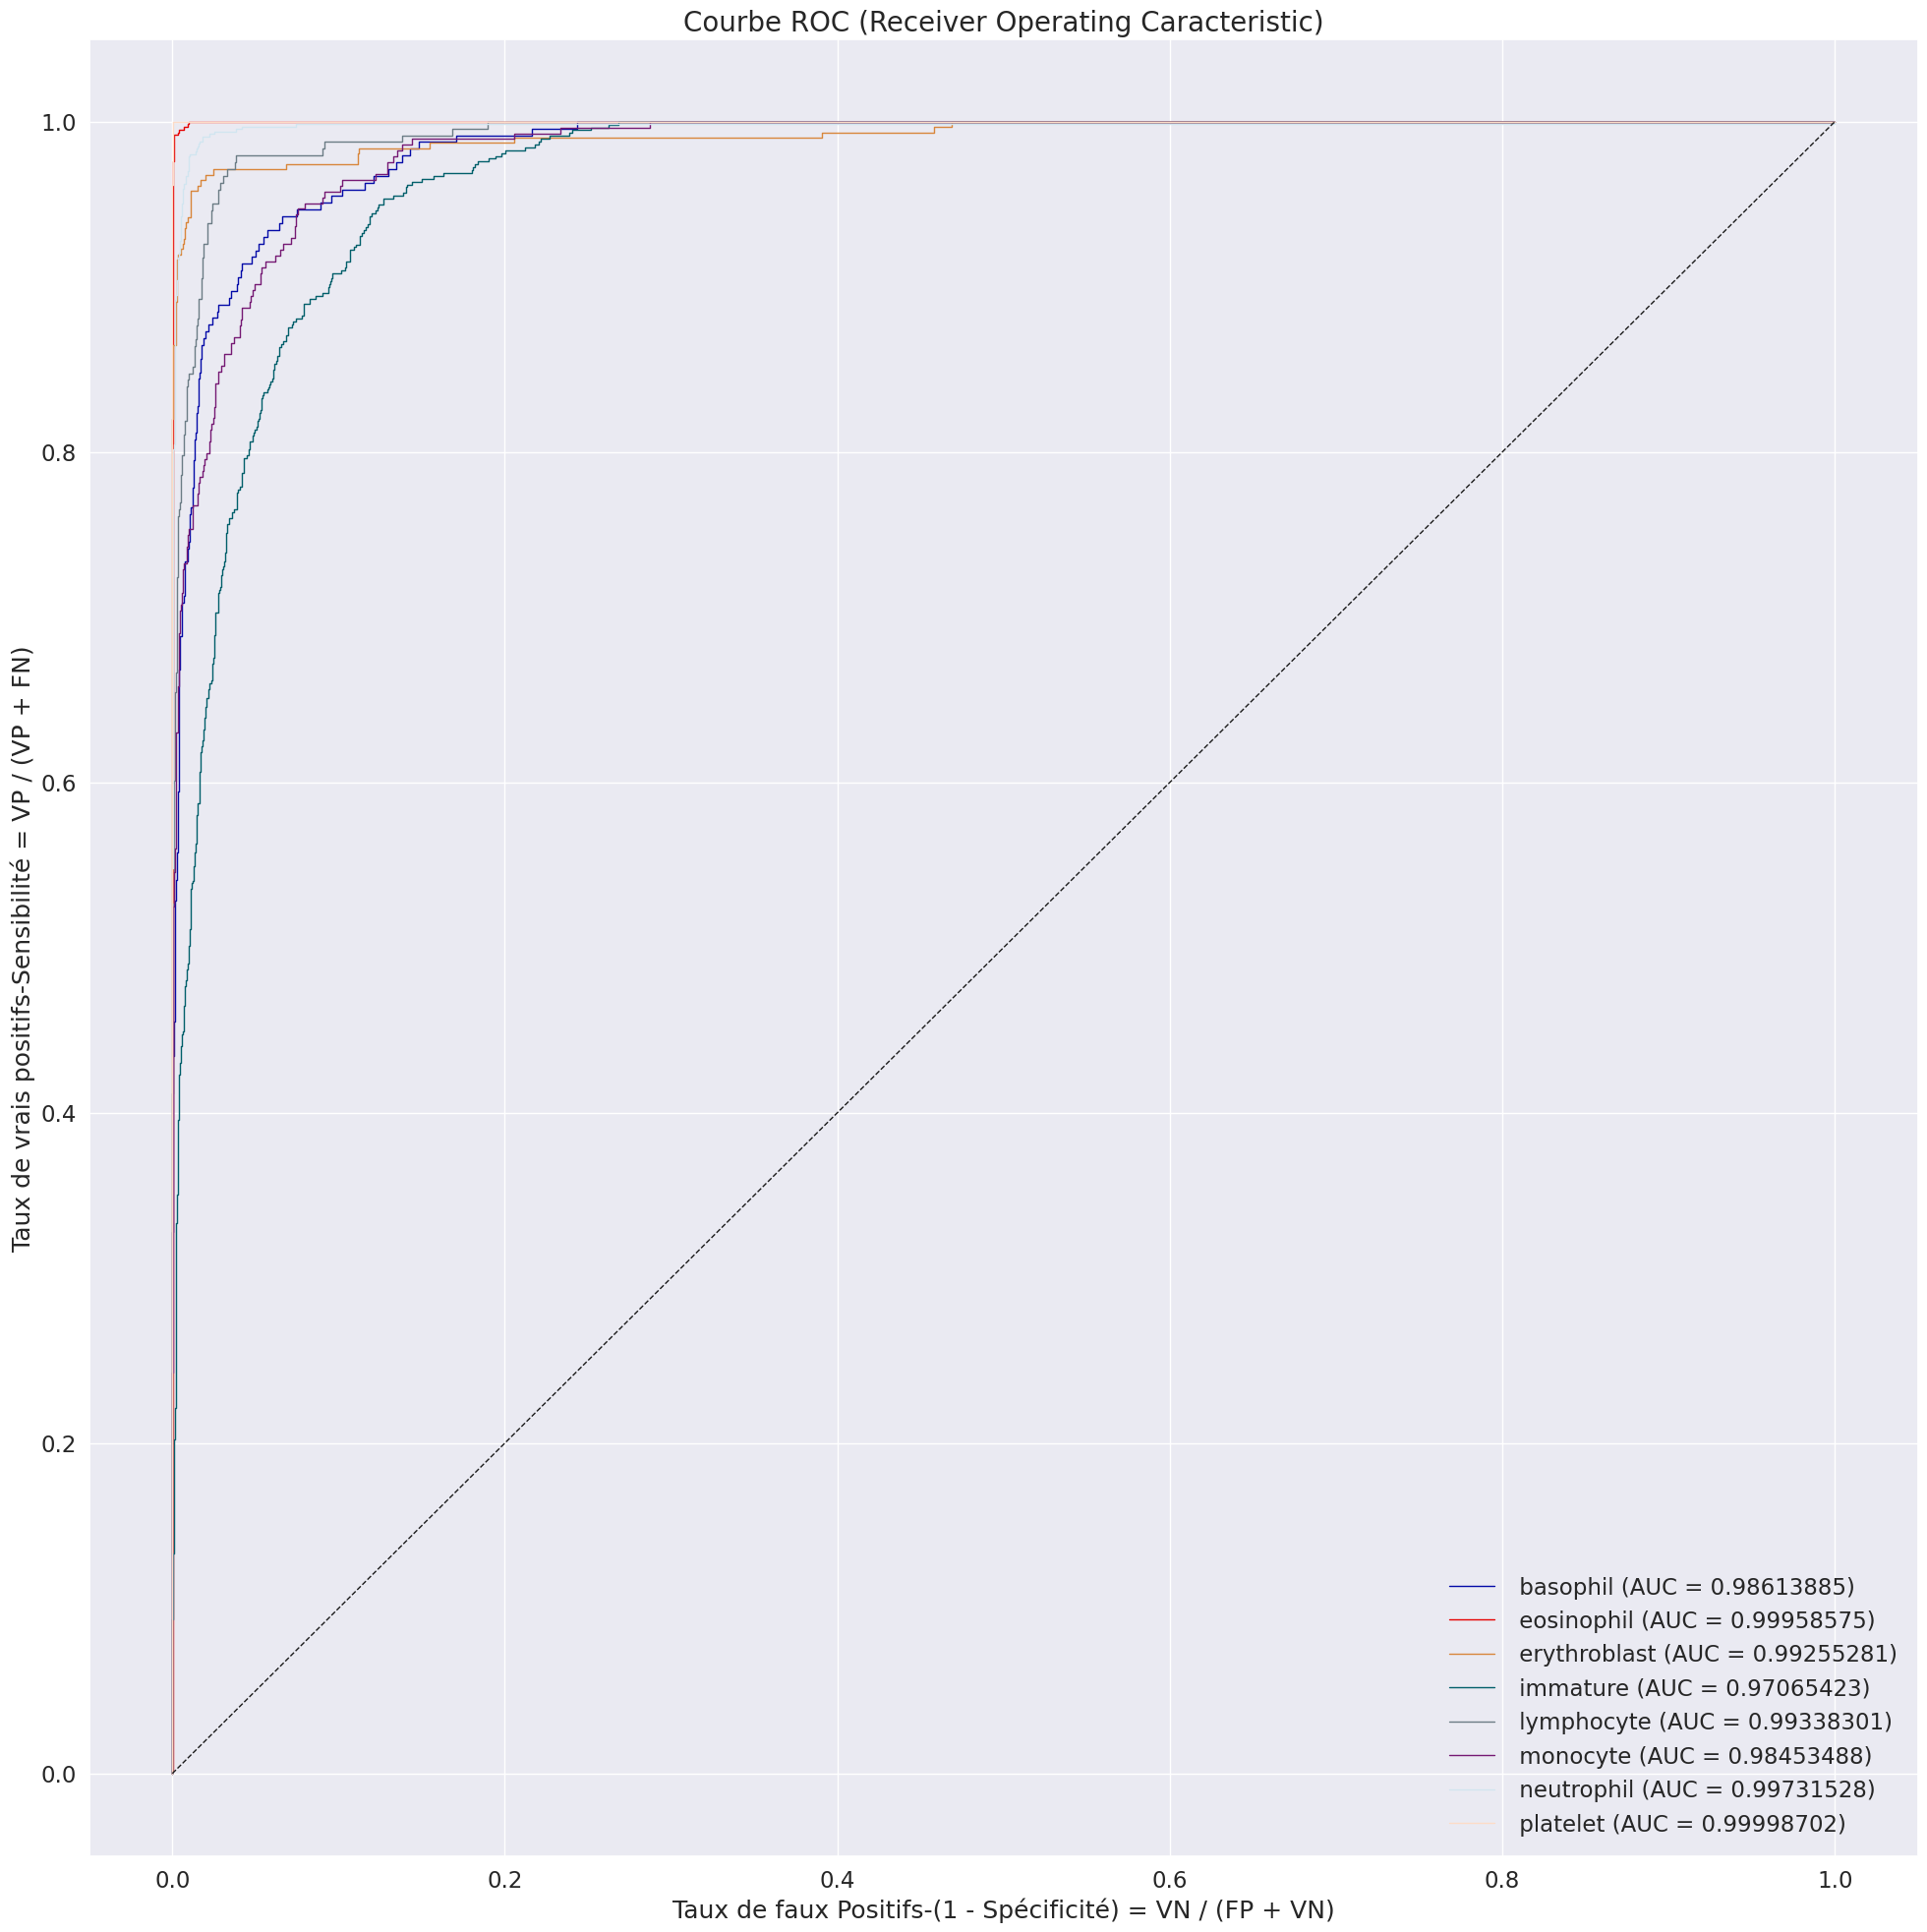

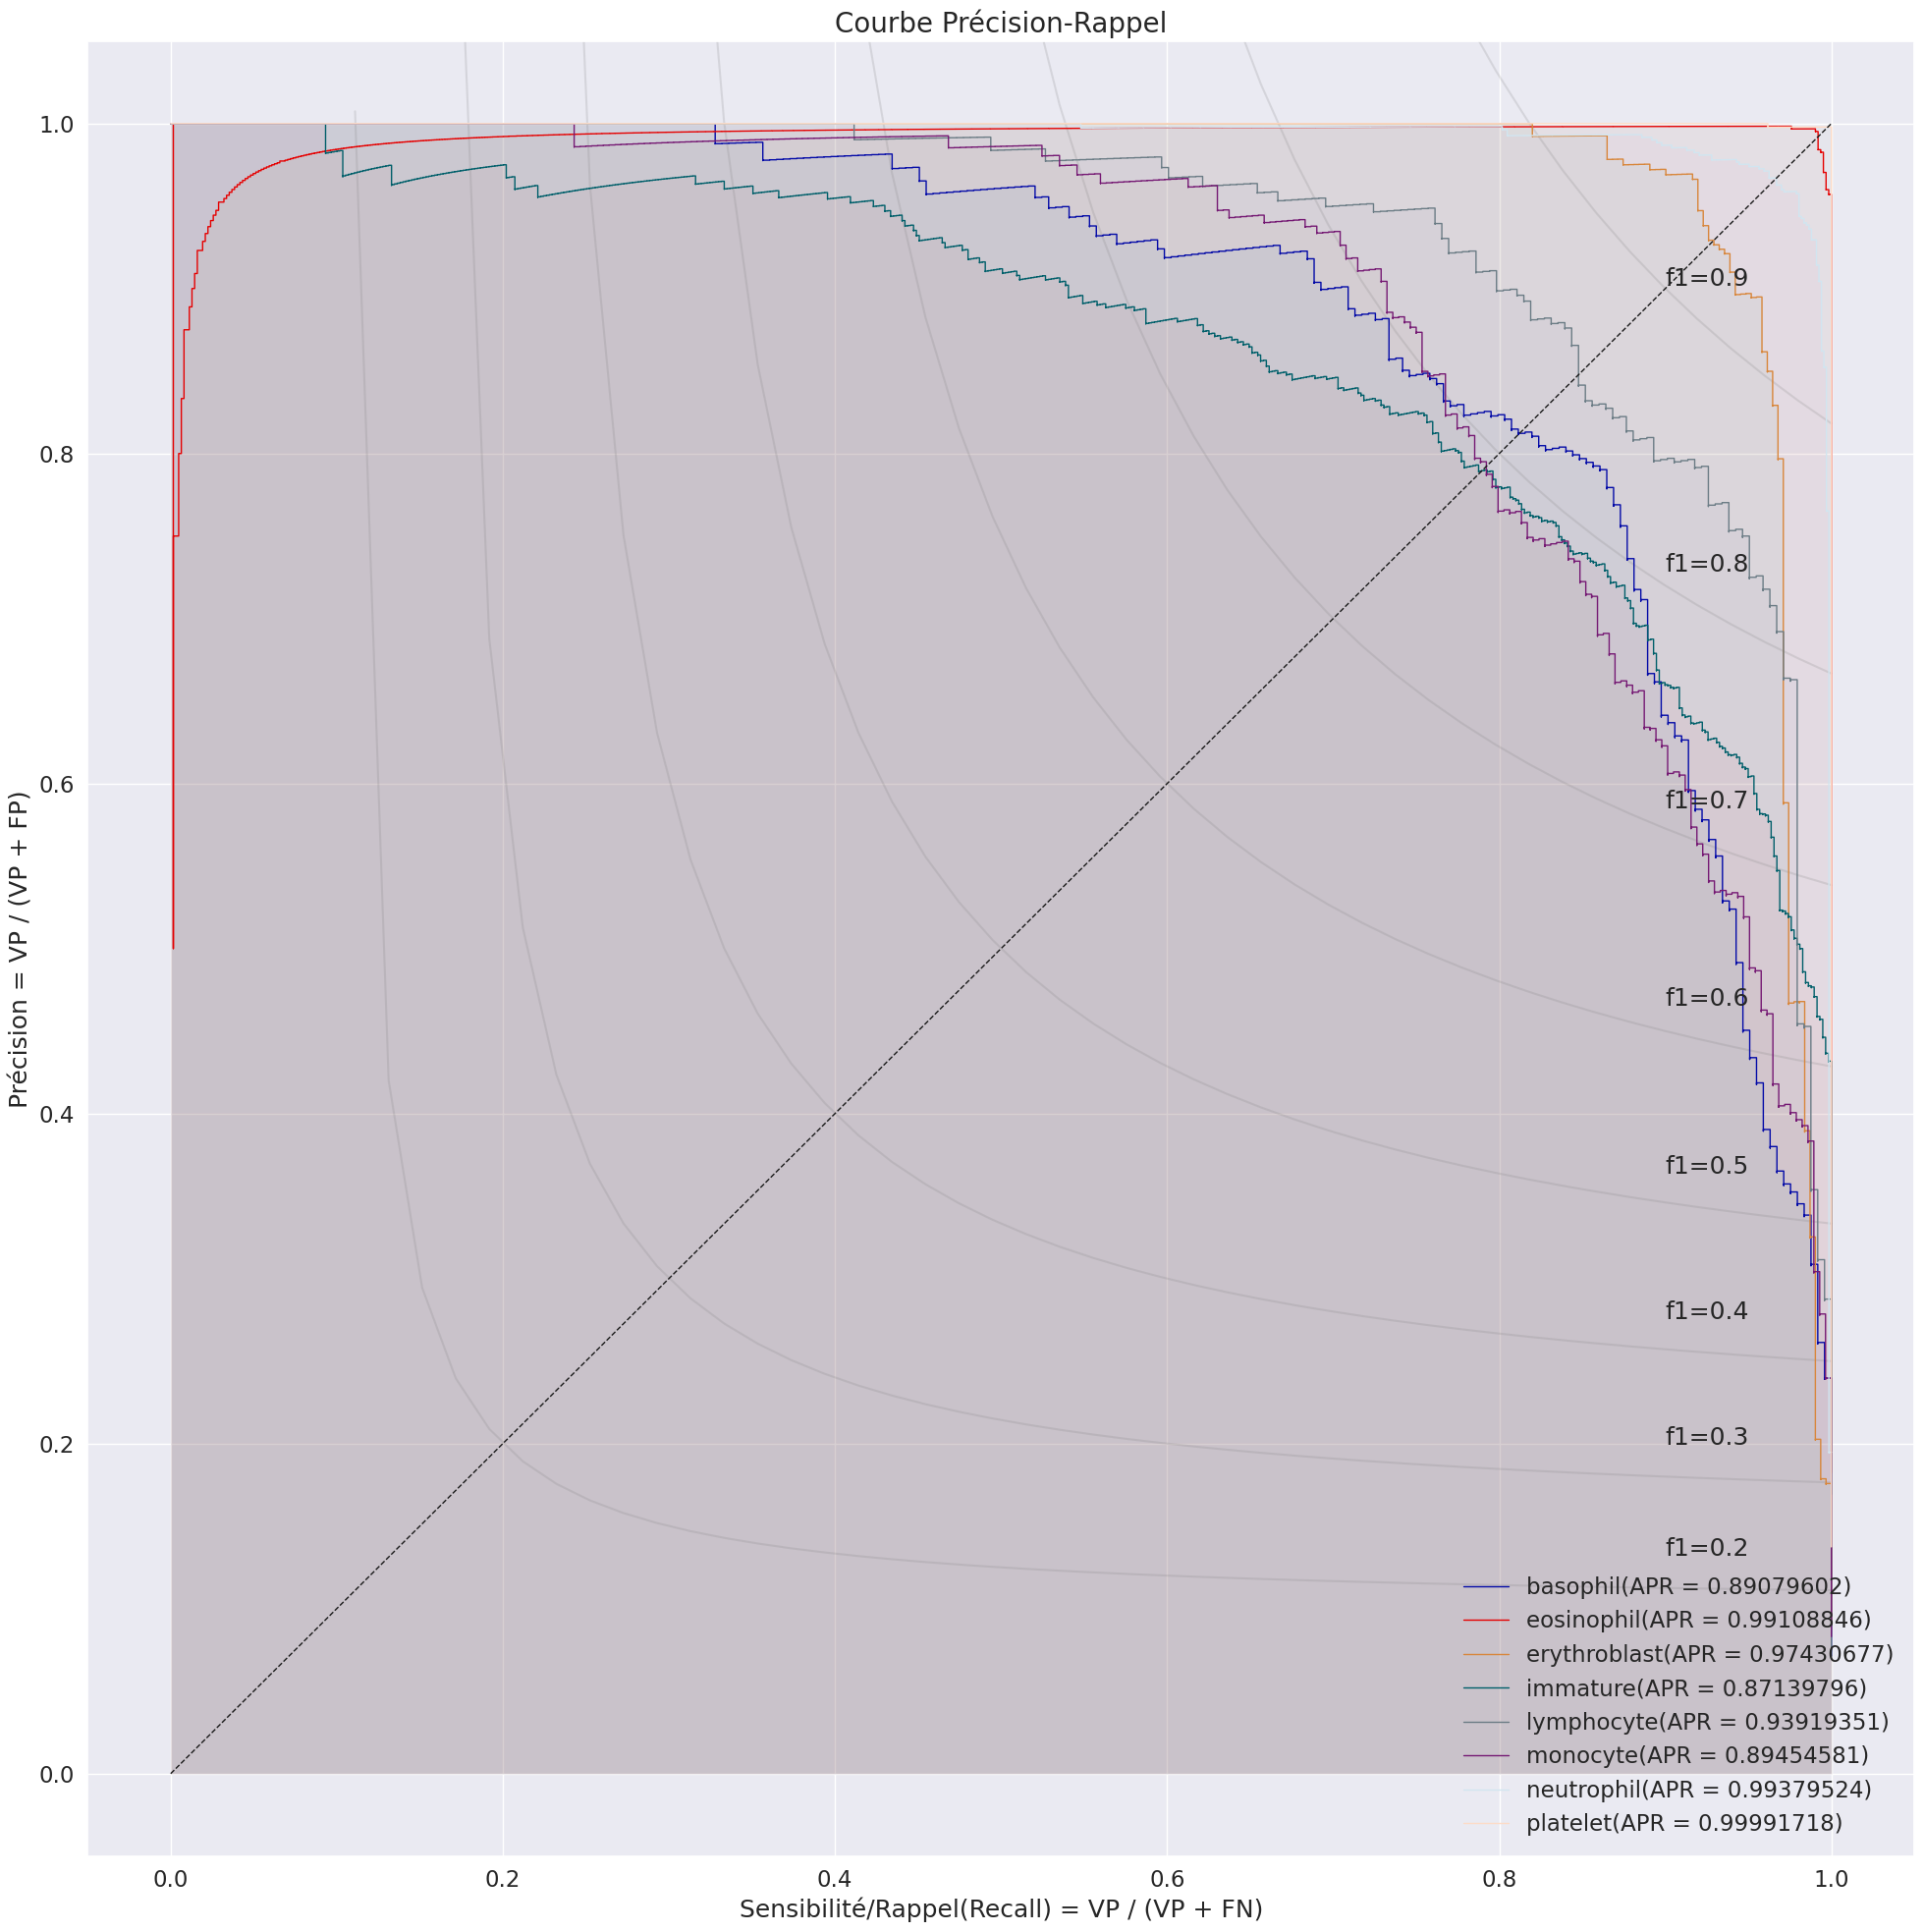

In [31]:
resultats = executeApprentissageChoixClassifieurs(
                                                  model,
                                                  X_test=images,
                                                  y_test=labels,
                                                  label_dict=dictLabels,
                                                  palette=palette,
                                                  repertoireEnregistrement=repertoireEnregistrement,
                                                  nom_essai = f'{nomModel}-bs{batch_size:02d}-epochs{epochs:03d}',
                                                 );

resultats.to_parquet(os.path.join(repertoireSauvegardes,f'resultats-{nomModel}-bs{batch_size:02d}-epochs{epochs:03d}.gzip'),compression='gzip', engine='pyarrow')

resultats